In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt

In [9]:
def hausdorff_level_sets(
    grid, # seq of 1D np arrays
    f,
    g, 
    threshold
) -> float:
    """
    Approximate Hausdorff distance between {f>=threshold} and {g>=threshold}.
    Returns np.inf if exactly on set is empty; 0.0 if both are empty.
    """
    axes = [np.asarray(a) for a in grid]
    spacings = tuple(float(a[1] - a[0]) for a in axes)

    # Build meshgrid and stack into a (..., d) array of points.
    mesh = np.meshgrid(*axes, indexing="ij")
    points = np.stack(mesh, axis=-1)

    F = f(points)
    G = g(points)

    A = F >= threshold
    B = G >= threshold

    if not A.any() and not B.any():
        return 0.0
    if not A.any() or not B.any():
        return np.inf

    # distance_transform_edt computes, for each False cell, the distance to
    # the nearest True cell. So to get distance from each cell in A to the
    # set B, we pass ~B (True outside B) -- wait, we want the opposite.
    # The convention is: the transform returns distance to the nearest
    # *zero* (False) cell. So to get "distance to B" we invert B.
    dist_to_B = distance_transform_edt(~B, sampling=spacings)
    dist_to_A = distance_transform_edt(~A, sampling=spacings)

    # sup_{x in A} d(x, B) and sup_{x in B} d(x, A)
    sup_A_to_B = dist_to_B[A].max()
    sup_B_to_A = dist_to_A[B].max()

    return float(max(sup_A_to_B, sup_B_to_A))

In [52]:
from algs.kern_cd import KernCD
from algs.kernels import *
from utils.plotting import plot_level_set

from scipy.stats import multivariate_normal

In [62]:
mean = np.zeros(2)
cov = np.eye(2)

dist = multivariate_normal(mean, cov)
x = dist.rvs(100)

In [64]:
def get_normal_thresh(mean, cov, probability=0.95):
    from scipy.stats import chi2
    mean = np.atleast_1d(mean)
    cov = np.atleast_2d(cov)
    
    k = len(mean) # Number of dimensions
    
    mahalanobis_sq_thresh = chi2.ppf(probability, df=k)

    det_cov = np.linalg.det(cov)
    peak_density = 1.0 / np.sqrt(((2 * np.pi) ** k) * det_cov)
    
    density_threshold = peak_density * np.exp(-0.5 * mahalanobis_sq_thresh)
    
    return density_threshold

t = get_normal_thresh(mean, cov)

In [65]:
t

np.float64(0.007957747154594776)

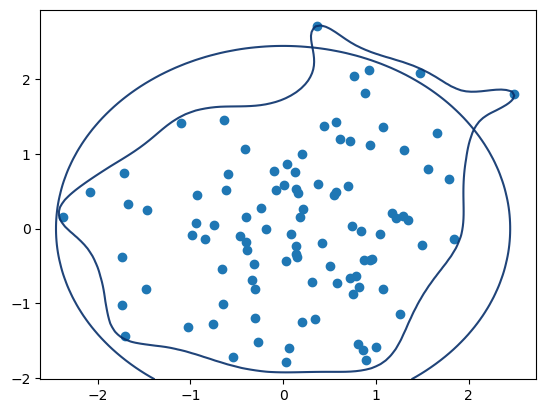

In [66]:
plt.scatter(*x.T)
kernel = RBF().fit(x)

lam = 1e-3
p = KernCD(kernel, reg=lam).fit(x)
f = lambda x: p.predict(x)
p_true = lambda x: dist.pdf(x)
plot_level_set(f, alpha=100)
plot_level_set(p_true, alpha=t)

In [57]:
p_true(x)

array([0.07703159, 0.10709144, 0.06549544, 0.06575135, 0.11981201,
       0.15567496, 0.09688617, 0.00692201, 0.09473049, 0.0307778 ,
       0.02814852, 0.03535675, 0.11486338, 0.04666168, 0.15724183,
       0.03283087, 0.0389214 , 0.04535578, 0.05421309, 0.15392643,
       0.07645542, 0.15652629, 0.14385741, 0.04815294, 0.1024332 ,
       0.01530672, 0.09256268, 0.09725048, 0.09249513, 0.13948842,
       0.13766646, 0.09630039, 0.07587182, 0.14195177, 0.08519338,
       0.02941073, 0.03450312, 0.10785545, 0.02736161, 0.14721087,
       0.14746888, 0.06693949, 0.04562607, 0.08515318, 0.13997118,
       0.1399592 , 0.12837921, 0.08716633, 0.06515881, 0.0603063 ,
       0.13875856, 0.0314628 , 0.03300412, 0.14050064, 0.0378951 ,
       0.09861749, 0.15090713, 0.11200751, 0.14580583, 0.05941846,
       0.10543284, 0.11318715, 0.04347969, 0.07928444, 0.06100414,
       0.11689912, 0.02839983, 0.10574556, 0.13289411, 0.09842543,
       0.03552576, 0.05822311, 0.05426912, 0.06142739, 0.10901

In [ ]:
import numpy as np
from scipy.stats import multivariate_normal
from sklearn.neighbors import KernelDensity
from sklearn.mixture import GaussianMixture


def sample_gaussian(mean, cov, n, rng):
    return rng.multivariate_normal(mean, cov, size=n)


def sample_truncated_gaussian(mean, cov, n, threshold, rng):
    """Sample from N(mean, cov) conditioned on pdf(x) >= threshold via rejection."""
    dist = multivariate_normal(mean=mean, cov=cov)
    d = len(np.atleast_1d(mean))
    out = np.empty((0, d))
    while len(out) < n:
        batch = rng.multivariate_normal(mean, cov, size=n)
        accepted = batch[dist.pdf(batch) >= threshold]
        out = np.concatenate([out, accepted], axis=0)
    return out[:n]


def gaussian_density(points, mean, cov):
    return multivariate_normal(mean=mean, cov=cov).pdf(points)


def fit_kde(train_samples, bandwidth):
    kde = KernelDensity(bandwidth=bandwidth).fit(train_samples)
    return lambda points: np.exp(
        kde.score_samples(points.reshape(-1, points.shape[-1]))
    ).reshape(points.shape[:-1])


def fit_gmm(train_samples, n_components):
    gmm = GaussianMixture(n_components=n_components).fit(train_samples)
    return lambda points: np.exp(
        gmm.score_samples(points.reshape(-1, points.shape[-1]))
    ).reshape(points.shape[:-1])


def calibrate_threshold(estimator, cal_samples, alpha):
    scores = estimator(cal_samples)
    m = len(cal_samples)
    k = int(np.floor(alpha * (m + 1)))
    k = max(1, min(k, m))
    return np.sort(scores)[k - 1]


def fn_area(estimator, threshold_f, true_density_fn, threshold_true, grid):
    axes = [np.asarray(a) for a in grid]
    cell_area = float(np.prod([a[1] - a[0] for a in axes]))
    mesh = np.meshgrid(*axes, indexing="ij")
    points = np.stack(mesh, axis=-1)
    outside_true = true_density_fn(points) < threshold_true
    not_flagged = estimator(points) >= threshold_f
    return float((outside_true & not_flagged).sum()) * cell_area


def run_one_trial(
    n_train, n_cal, true_mean, true_cov,
    threshold_true, alpha, estimator_factories, grid, rng,
):
    train = sample_truncated_gaussian(true_mean, true_cov, n_train, threshold_true, rng)
    cal = sample_truncated_gaussian(true_mean, true_cov, n_cal, threshold_true, rng)
    true_density_fn = lambda pts: gaussian_density(pts, true_mean, true_cov)
    results = {}
    for name, factory in estimator_factories.items():
        estimator = factory(train)
        threshold_f = calibrate_threshold(estimator, cal, alpha)
        results[name] = fn_area(
            estimator, threshold_f, true_density_fn, threshold_true, grid
        )
    return results

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def run_experiment(
    sample_sizes, n_trials, true_mean, true_cov,
    threshold_true, alpha, estimator_factories, grid, rng,
):
    names = list(estimator_factories.keys())
    n_cal = 2000
    out = {name: np.zeros((len(sample_sizes), n_trials)) for name in names}
    last_estimators = {name: [None] * len(sample_sizes) for name in names}
    last_thresholds = {name: [None] * len(sample_sizes) for name in names}

    for i, n in enumerate(sample_sizes):
        for t in range(n_trials):
            train = sample_truncated_gaussian(
                true_mean, true_cov, n, threshold_true, rng
            )
            cal = sample_truncated_gaussian(
                true_mean, true_cov, n_cal, threshold_true, rng
            )
            true_density_fn = lambda pts: gaussian_density(pts, true_mean, true_cov)
            for name, factory in estimator_factories.items():
                estimator = factory(train)
                threshold_f = calibrate_threshold(estimator, cal, alpha)
                out[name][i, t] = fn_area(
                    estimator, threshold_f, true_density_fn, threshold_true, grid
                )
                if t == n_trials - 1:
                    last_estimators[name][i] = estimator
                    last_thresholds[name][i] = threshold_f

    axes = [np.asarray(a) for a in grid]
    mesh = np.meshgrid(*axes, indexing="ij")
    points = np.stack(mesh, axis=-1)
    true_vals = gaussian_density(points, true_mean, true_cov)

    for name in names:
        n_panels = len(sample_sizes)
        ncols = min(4, n_panels)
        nrows = int(np.ceil(n_panels / ncols))
        fig, axarr = plt.subplots(
            nrows, ncols, figsize=(4 * ncols, 4 * nrows), squeeze=False
        )
        for i, n in enumerate(sample_sizes):
            ax = axarr[i // ncols][i % ncols]
            est_vals = last_estimators[name][i](points)
            ax.contour(
                axes[0], axes[1], true_vals.T,
                levels=[threshold_true], colors="black", linewidths=2,
            )
            ax.contour(
                axes[0], axes[1], est_vals.T,
                levels=[last_thresholds[name][i]], colors="red", linewidths=1.5,
            )
            ax.set_title(f"n_train={n}")
            ax.set_aspect("equal")
        for j in range(n_panels, nrows * ncols):
            axarr[j // ncols][j % ncols].axis("off")
        fig.suptitle(f"{name}: estimated (red) vs true (black) level set")
        fig.tight_layout()
        plt.show()

    return out

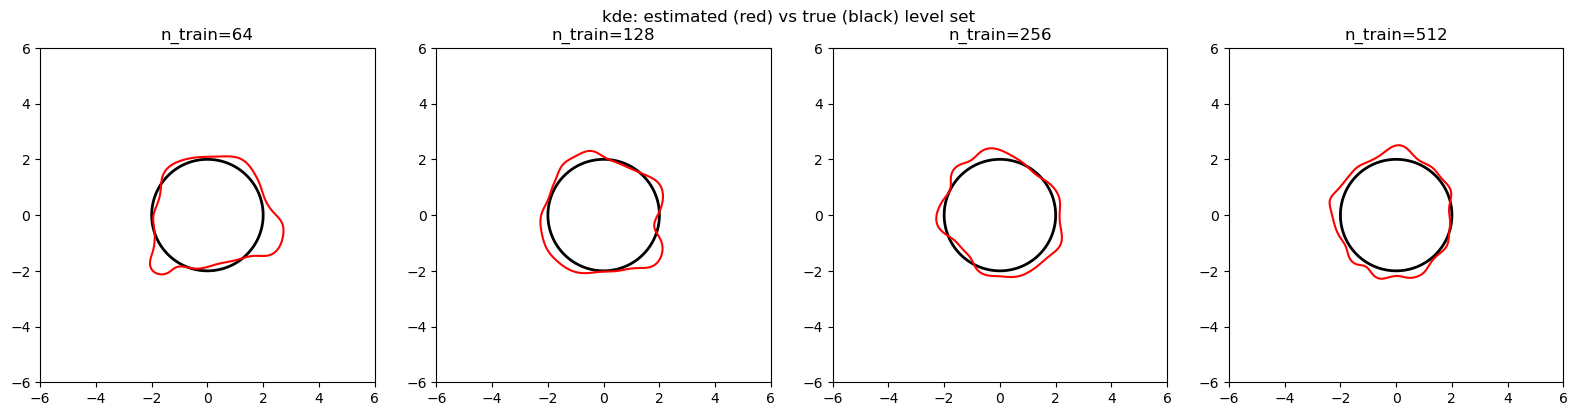

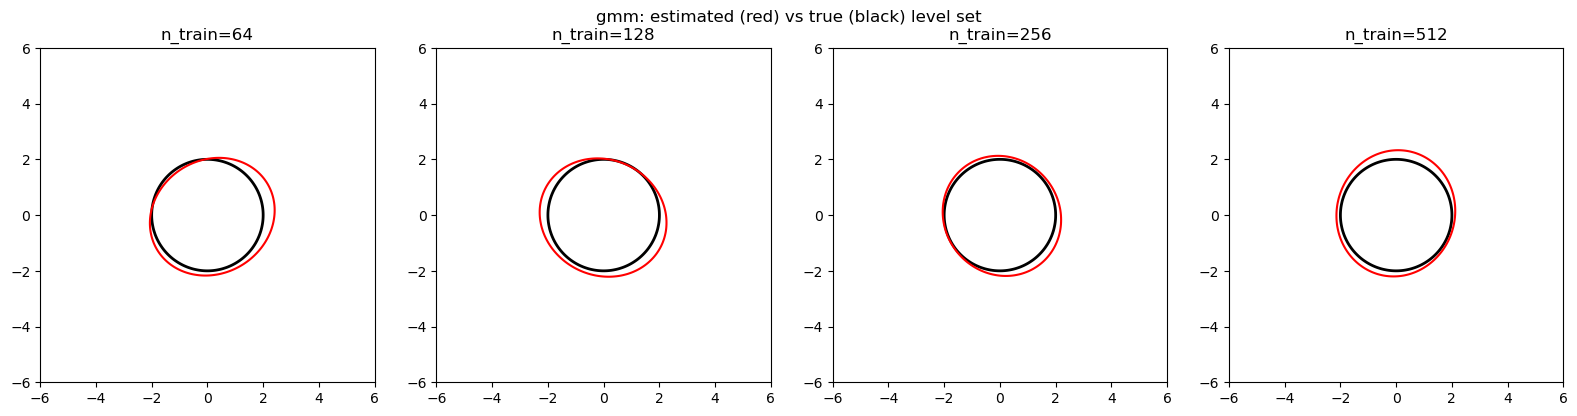

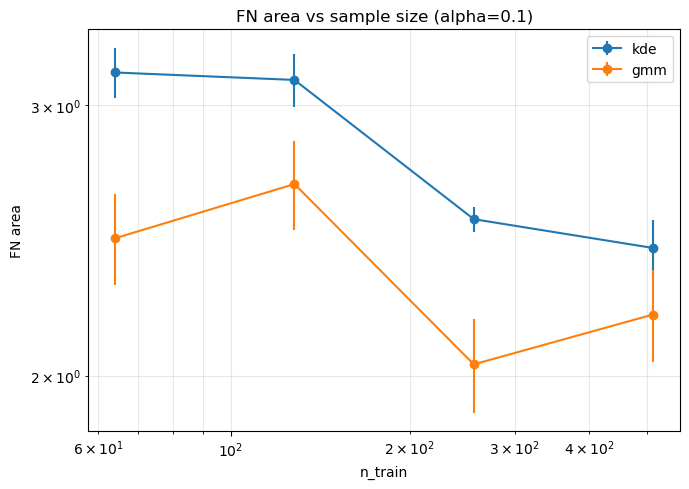

In [77]:
import numpy as np
import matplotlib.pyplot as plt


rng = np.random.default_rng(0)

d = 2
true_mean = np.zeros(d)
true_cov = np.eye(d)

threshold_true = multivariate_normal(mean=true_mean, cov=true_cov).pdf(
    np.array([2.0, 0.0])
)

alpha = 0.1

axis = np.linspace(-6, 6, 200)
grid = (axis, axis)

sample_sizes = [64, 128, 256, 512]
n_trials = 5

estimator_factories = {
    "kde": lambda train: fit_kde(train, bandwidth=len(train) ** (-1 / (d + 4))),
    "gmm": lambda train: fit_gmm(train, n_components=1),
}

results = run_experiment(
    sample_sizes=sample_sizes,
    n_trials=n_trials,
    true_mean=true_mean,
    true_cov=true_cov,
    threshold_true=threshold_true,
    alpha=alpha,
    estimator_factories=estimator_factories,
    grid=grid,
    rng=rng,
)

plt.figure(figsize=(7, 5))
for name, arr in results.items():
    mean = arr.mean(axis=1)
    se = arr.std(axis=1) / np.sqrt(n_trials)
    plt.errorbar(sample_sizes, mean, yerr=se, label=name, marker="o")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("n_train")
plt.ylabel("FN area")
plt.title(f"FN area vs sample size (alpha={alpha})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()